<a href="https://colab.research.google.com/github/hsmu-jeongeun/health-infomatics/blob/main/11_SQLite_Patient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11주차 실습: SQLite 기반 환자 데이터 추출

## 학습 목표
- 관계형 데이터베이스(RDB)의 기본 개념을 이해할 수 있다
- SQL의 기초 문법(SELECT, WHERE, JOIN)을 사용할 수 있다
- Python에서 SQLite를 이용해 가상 병원 DB를 만들고 쿼리할 수 있다

---

## 오늘의 핵심 개념: 병원 데이터는 어디에 저장되는가?

> 도서관을 생각했을 때 책은 여러 서가에 분류되어 있고, 사서에게 '의학 분야 중 2020년 이후 발행된 책을 찾아줘'라고 요청
>
> SQL은 데이터베이스를 검색하는 언어.
>
> 책 = 데이터, 서가 = 데이터베이스, 사서 = SQL

### 데이터베이스(DB)란?
- **관계형 데이터베이스(RDB):** 데이터를 테이블(표) 형태로 저장. Oracle, MySQL, PostgreSQL 등
- **병원 DB 구조:**
  - 환자(Patients) 테이블, 진단(Diagnoses) 테이블, 처방(Prescriptions) 테이블 등
  - 테이블 간 관계로 연결 (JOIN)

### SQL 핵심 문법
```sql
SELECT 열이름
FROM 테이블명
WHERE 조건
```

### SQLite 특징
- 별도 서버 없이 파일 하나로 동작하는 가벼운 DB
- Python 기본 내장 라이브러리 (`import sqlite3`)
- 실습·프로토타입에 최적

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료!')
print(f'SQLite 버전: {sqlite3.sqlite_version}')

라이브러리 로드 완료!
SQLite 버전: 3.37.2


## Step 1. 가상 병원 데이터베이스 구축

### 테이블 명세서

**patients (환자 테이블)**
| 컬럼 | 타입 | 설명 |
|------|------|------|
| patient_id | INT | 환자 고유번호 (PK) |
| name | TEXT | 이름 |
| age | INT | 나이 |
| gender | TEXT | 성별 |
| admission_date | TEXT | 입원일 |

**diagnoses (진단 테이블)**
| 컬럼 | 타입 | 설명 |
|------|------|------|
| diag_id | INT | 진단 고유번호 (PK) |
| patient_id | INT | 환자 고유번호 (FK) |
| disease_code | TEXT | 질병 코드 (ICD-10) |
| disease_name | TEXT | 질병명 |
| diagnosis_date | TEXT | 진단일 |

In [2]:
# 메모리 내 SQLite DB 생성
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# 환자 테이블 생성
cursor.execute('''
CREATE TABLE patients (
    patient_id     INTEGER PRIMARY KEY,
    name           TEXT,
    age            INTEGER,
    gender         TEXT,
    admission_date TEXT
)
''')

# 진단 테이블 생성
cursor.execute('''
CREATE TABLE diagnoses (
    diag_id        INTEGER PRIMARY KEY,
    patient_id     INTEGER,
    disease_code   TEXT,
    disease_name   TEXT,
    diagnosis_date TEXT,
    FOREIGN KEY (patient_id) REFERENCES patients(patient_id)
)
''')

print('테이블 생성 완료!')

테이블 생성 완료!


In [3]:
# 환자 데이터 삽입 (150명)
np.random.seed(42)

male_names   = ['김민준', '이준서', '박도윤', '최시우', '정주원', '강지후', '조건우', '윤우진', '장현서', '임서준']
female_names = ['김서연', '이수아', '박지아', '최하은', '정민서', '강예은', '조채원', '윤수빈', '장나은', '임지유']

patients_data = []
for pid in range(1, 151):
    gender = np.random.choice(['M', 'F'])
    name   = np.random.choice(male_names) if gender == 'M' else np.random.choice(female_names)
    age    = int(np.random.randint(18, 90))
    month  = np.random.randint(1, 13)
    day    = np.random.randint(1, 28)
    adm    = f'2025-{month:02d}-{day:02d}'
    patients_data.append((pid, name, age, gender, adm))

cursor.executemany('INSERT INTO patients VALUES (?,?,?,?,?)', patients_data)

# 진단 데이터 삽입
disease_map = {
    'I10':  '본태성 고혈압',
    'E11':  '제2형 당뇨병',
    'J18':  '폐렴',
    'I50':  '심부전',
    'N39':  '요로감염',
    'K40':  '서혜부 탈장',
    'M54':  '요통',
    'Z96':  '인공삽입물 존재'
}
all_codes = list(disease_map.keys())

diag_data = []
did = 1
for pid in range(1, 151):
    n_diag = np.random.randint(1, 4)
    codes  = np.random.choice(all_codes, n_diag, replace=False)
    for code in codes:
        month = np.random.randint(1, 13)
        day   = np.random.randint(1, 28)
        ddate = f'2025-{month:02d}-{day:02d}'
        diag_data.append((did, pid, code, disease_map[code], ddate))
        did += 1

cursor.executemany('INSERT INTO diagnoses VALUES (?,?,?,?,?)', diag_data)
conn.commit()

print(f'환자 {len(patients_data)}명 삽입 완료!')
print(f'진단 기록 {len(diag_data)}건 삽입 완료!')

환자 150명 삽입 완료!
진단 기록 302건 삽입 완료!


## Step 2. SQL 기초 쿼리 연습

In [4]:
# 쿼리 1: 모든 환자 조회 (첫 10명)
print('=== 쿼리 1: SELECT 기본 ===')
result = pd.read_sql_query('SELECT * FROM patients LIMIT 10', conn)
print(result)

=== 쿼리 1: SELECT 기본 ===
   patient_id name  age gender admission_date
0           1  최시우   32      M     2025-11-08
1           2  정주원   41      M     2025-03-22
2           3  이준서   47      M     2025-06-02
3           4  정민서   50      F     2025-12-26
4           5  장나은   66      F     2025-11-27
5           6  임서준   77      M     2025-03-12
6           7  최시우   81      M     2025-09-03
7           8  박도윤   24      M     2025-05-09
8           9  이준서   21      M     2025-09-14
9          10  임지유   26      F     2025-10-21


In [5]:
# 쿼리 2: WHERE — 65세 이상 환자
print('=== 쿼리 2: WHERE — 65세 이상 환자 ===')
result2 = pd.read_sql_query('SELECT * FROM patients WHERE age >= 65', conn)
print(f'65세 이상 환자: {len(result2)}명')
print(result2.head())

=== 쿼리 2: WHERE — 65세 이상 환자 ===
65세 이상 환자: 50명
   patient_id name  age gender admission_date
0           5  장나은   66      F     2025-11-27
1           6  임서준   77      M     2025-03-12
2           7  최시우   81      M     2025-09-03
3          11  최하은   77      F     2025-07-12
4          13  최시우   67      M     2025-08-04


In [6]:
# 쿼리 3: JOIN — 환자 + 진단 연결
print('=== 쿼리 3: INNER JOIN ===')
join_query = '''
SELECT p.patient_id, p.name, p.age, p.gender, d.disease_code, d.disease_name
FROM patients p
INNER JOIN diagnoses d ON p.patient_id = d.patient_id
LIMIT 10
'''
result3 = pd.read_sql_query(join_query, conn)
print(result3)

=== 쿼리 3: INNER JOIN ===
   patient_id name  age gender disease_code disease_name
0           1  최시우   32      M          N39         요로감염
1           1  최시우   32      M          I50          심부전
2           2  정주원   41      M          K40       서혜부 탈장
3           3  이준서   47      M          M54           요통
4           3  이준서   47      M          E11      제2형 당뇨병
5           3  이준서   47      M          Z96     인공삽입물 존재
6           4  정민서   50      F          M54           요통
7           4  정민서   50      F          I50          심부전
8           5  장나은   66      F          I10      본태성 고혈압
9           6  임서준   77      M          N39         요로감염


## Step 3. 핵심 쿼리: 65세 이상 + 고혈압(I10) 환자 추출

In [7]:
# Canvas 퀴즈 대상 쿼리
# =====================
# 수정해 보세요!
# =====================
age_limit    = 65      # 나이 기준 변경 가능
disease_code = 'I10'   # 질병 코드 변경 가능 (E11, J18 등)
# =====================

target_query = f'''
SELECT p.patient_id, p.name, p.age, p.gender, d.disease_code, d.disease_name
FROM patients p
INNER JOIN diagnoses d ON p.patient_id = d.patient_id
WHERE p.age >= {age_limit}
  AND d.disease_code = '{disease_code}'
'''

result_target = pd.read_sql_query(target_query, conn)
print(f'=== 나이 >= {age_limit} AND 질병코드 = {disease_code} ===')
print(f'추출된 환자 수: {len(result_target)}명')
print(result_target)

=== 나이 >= 65 AND 질병코드 = I10 ===
추출된 환자 수: 17명
    patient_id name  age gender disease_code disease_name
0            5  장나은   66      F          I10      본태성 고혈압
1            7  최시우   81      M          I10      본태성 고혈압
2           17  장현서   79      M          I10      본태성 고혈압
3           36  장나은   79      F          I10      본태성 고혈압
4           53  임서준   77      M          I10      본태성 고혈압
5           65  박도윤   71      M          I10      본태성 고혈압
6           80  최시우   82      M          I10      본태성 고혈압
7           82  조채원   80      F          I10      본태성 고혈압
8           92  정민서   79      F          I10      본태성 고혈압
9           94  이준서   65      M          I10      본태성 고혈압
10          99  임지유   65      F          I10      본태성 고혈압
11         113  윤우진   81      M          I10      본태성 고혈압
12         121  장현서   69      M          I10      본태성 고혈압
13         133  이준서   75      M          I10      본태성 고혈압
14         135  장현서   80      M          I10      본태성 고혈압
15         140  김서연   71  

/tmp/ipykernel_14311/4272137484.py:17: UserWarning: Glyph 51652 (\N{HANGUL SYLLABLE JIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14311/4272137484.py:17: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14311/4272137484.py:17: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14311/4272137484.py:17: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14311/4272137484.py:17: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14311/4272137484.py:17: UserWarning: Glyph 54812 (\N{HANGUL SYLLABLE HYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14311/4272137484.py:17: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.t

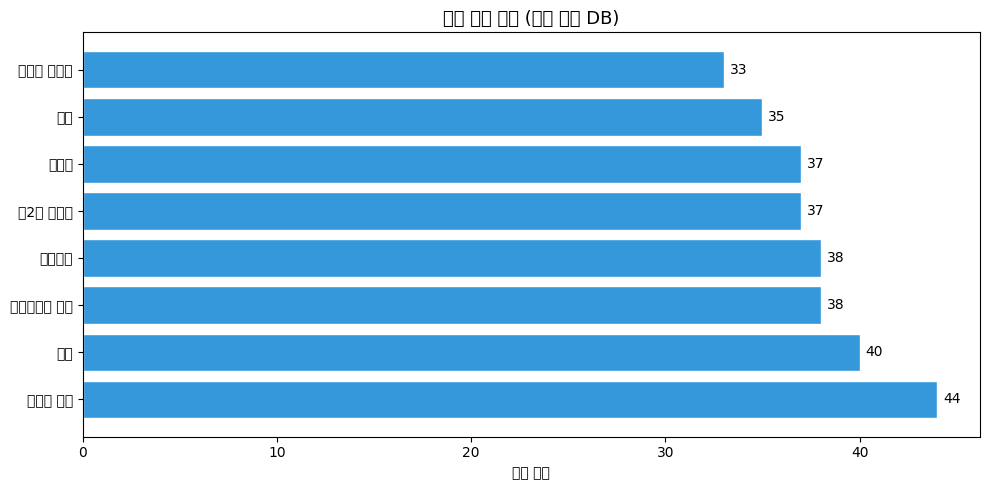

In [8]:
# 질병별 환자 분포 시각화
disease_counts = pd.read_sql_query('''
SELECT disease_name, COUNT(*) as count
FROM diagnoses
GROUP BY disease_name
ORDER BY count DESC
''', conn)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(disease_counts['disease_name'], disease_counts['count'],
               color='#3498db', edgecolor='white')
ax.set_title('전체 진단 분포 (가상 병원 DB)', fontsize=13)
ax.set_xlabel('진단 건수')
for bar, val in zip(bars, disease_counts['count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center')
plt.tight_layout()
plt.show()

---

## 퀴즈 안내

아래 코드 셀을 실행하여 나온 숫자를 퀴즈의 정답으로 업로드하세요.

**문제:** SQL 쿼리 `SELECT ... WHERE 나이 >= 65 AND 질병코드 = 'I10'`를 실행하여 추출된 **환자의 수**는?

In [ ]:
# [실습] 아래 코드를 실행하여 나온 결과를 퀴즈의 정답으로 제출
canvas_answer = len(result_target)
print(f'Answer: {canvas_answer}')